In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
dataset_path = "."

In [ ]:
images = []
labels = []

categories = ["cat", "dog"]

IMG_SIZE = 64
MAX_IMAGES = 1000   # Load only 1000 images per class

for category in categories:

    folder = category
    label = categories.index(category)

    count = 0

    for image in os.listdir(folder):

        if count >= MAX_IMAGES:
            break

        try:

            img = cv2.imread(os.path.join(folder, image))

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img = img / 255.0

            images.append(img.flatten())

            labels.append(label)

            count += 1

        except Exception as e:
            print("Error loading:", image)

X = np.array(images)
y = np.array(labels)

print("Total Images Loaded:", len(X))

Total Images Loaded: 2000


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 1600
Testing Images: 400


In [6]:
model = SVC(
    kernel='linear'
)

model.fit(X_train, y_train)

print("Model Trained Successfully")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Model Trained Successfully
Accuracy: 0.5625


              precision    recall  f1-score   support

         Cat       0.56      0.60      0.58       199
         Dog       0.57      0.52      0.55       201

    accuracy                           0.56       400
   macro avg       0.56      0.56      0.56       400
weighted avg       0.56      0.56      0.56       400



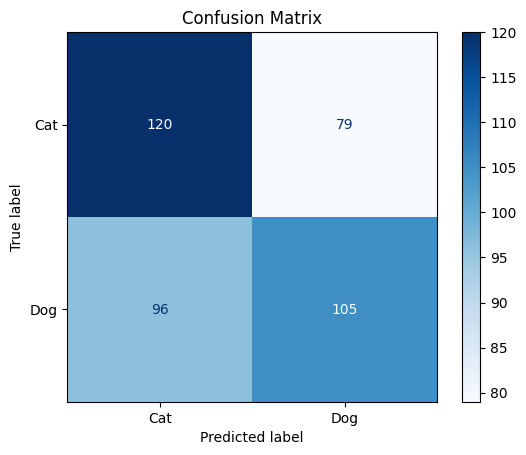

In [7]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()